In [92]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, BatchNormalization,
    ReLU, GlobalAveragePooling2D, Dropout
)

In [93]:
dataset_path = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

classes = ["benign", "malignant", "normal"]

In [94]:
image_paths = []
labels = []

for label in classes:
    folder = os.path.join(dataset_path, label)
    
    for file in os.listdir(folder):
        if "mask" not in file:   # remove mask images
            image_paths.append(os.path.join(folder, file))
            labels.append(label)

data = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

data.head()

,image_path,label
0,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign
1,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign
2,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign
3,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign
4,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign


In [95]:
print("Total images:", len(data))
data['label'].value_counts()

Total images: 780


label
benign       437
malignant    210
normal       133
Name: count, dtype: int64

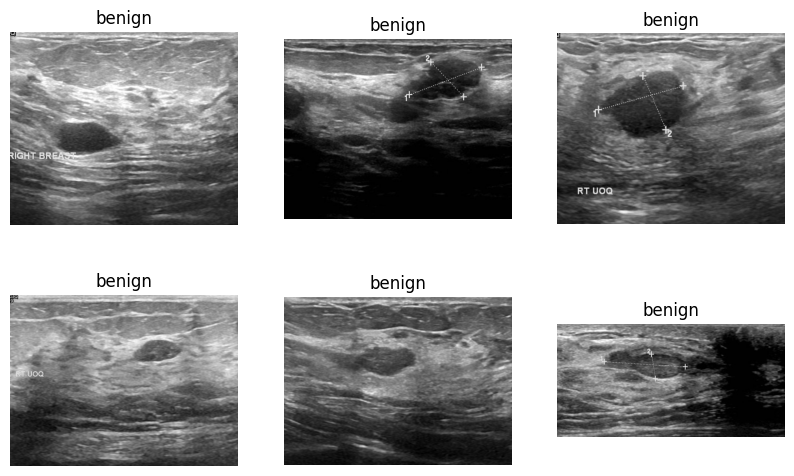

In [96]:
plt.figure(figsize=(10,6))

for i in range(6):
    img = Image.open(data.image_path[i])
    
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(data.label[i])
    plt.axis("off")

plt.show()

In [97]:
train_df, test_df = train_test_split(
    data,
    test_size=0.2,
    stratify=data['label'],
    random_state=42
)

In [98]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [99]:
train_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 156 validated image filenames belonging to 3 classes.


In [100]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)


Class Weights: {0: np.float64(0.5942857142857143), 1: np.float64(1.2380952380952381), 2: np.float64(1.9622641509433962)}


## Experiment 1: Baseline Model (No Class Imbalance Handling)


In [101]:
def depthwise_block(x, filters, strides=(1,1)):

    x = DepthwiseConv2D((3,3), strides=strides, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(filters, (1,1), padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    return x


def build_model():

    inputs = Input(shape=(128,128,3))

    x = Conv2D(16, (3,3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Block 1
    x = DepthwiseConv2D((3,3), padding='same')(x)
    x = Conv2D(32, (1,1), padding='same')(x)
    x = ReLU()(x)

    # Block 2
    x = DepthwiseConv2D((3,3), strides=2, padding='same')(x)
    x = Conv2D(64, (1,1), padding='same')(x)
    x = ReLU()(x)

    # Block 3
    x = DepthwiseConv2D((3,3), padding='same')(x)
    x = Conv2D(64, (1,1), padding='same')(x)
    x = ReLU()(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(32, activation="relu")(x)
    x = Dropout(0.5)(x)

    outputs = Dense(3, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # increased
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [102]:
model_baseline = build_model()

history_baseline = model_baseline.fit(
    train_generator,
    validation_data=test_generator,
    epochs=25
)

Epoch 1/25
18/20 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step - accuracy: 0.4843 - loss: 1.0833

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 645ms/step - accuracy: 0.4927 - loss: 1.0799 - val_accuracy: 0.5577 - val_loss: 1.0096
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 379ms/step - accuracy: 0.5454 - loss: 1.0236 - val_accuracy: 0.5577 - val_loss: 0.9866
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 379ms/step - accuracy: 0.5686 - loss: 0.9890 - val_accuracy: 0.5577 - val_loss: 0.9841
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 386ms/step - accuracy: 0.5919 - loss: 0.9766 - val_accuracy: 0.5577 - val_loss: 0.9871
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 399ms/step - accuracy: 0.5706 - loss: 0.9785 - val_accuracy: 0.5577 - val_loss: 0.9799
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 381ms/step - accuracy: 0.5524 - loss: 0.9935 - val_accuracy: 0.5577 - val_loss: 0.9816
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 376ms/step - accuracy: 0.5305 - loss: 1.0294 - val_accuracy: 0.5577 - val_loss: 0.9850
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 377ms/step - accuracy: 0.5717 - loss: 0.9658 - val_accuracy: 0.5577 - val

## Experiment 2: Class Weight Balancing

In [103]:
model = build_model()

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=25,
    class_weight=class_weights
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 648ms/step - accuracy: 0.3123 - loss: 1.1036 - val_accuracy: 0.2692 - val_loss: 1.0991
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.3457 - loss: 1.0657 - val_accuracy: 0.5577 - val_loss: 1.0974
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 377ms/step - accuracy: 0.4273 - loss: 1.0872 - val_accuracy: 0.5577 - val_loss: 1.0967
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.5267 - loss: 1.0878 - val_accuracy: 0.5577 - val_loss: 1.0971
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 371ms/step - accuracy: 0.4186 - loss: 1.0868 - val_accuracy: 0.2692 - val_loss: 1.0977
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 372ms/step - accuracy: 0.3990 - loss: 1.0856 - val_accuracy: 0.5577 - val_loss: 1.0965
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 380ms/step - accuracy: 0.3649 - loss: 1.0987 - val_accuracy: 0.5577 - val_loss: 1.0947
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 381ms/step - accuracy: 0.3773 - loss: 1.0980 - val_accuracy: 0

In [104]:
pred = model.predict(test_generator)
pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes
labels = list(test_generator.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=labels))

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step
              precision    recall  f1-score   support

      benign       0.61      0.87      0.72        87
   malignant       0.44      0.33      0.38        42
      normal       0.00      0.00      0.00        27

    accuracy                           0.58       156
   macro avg       0.35      0.40      0.37       156
weighted avg       0.46      0.58      0.50       156



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Experiment 3: SMOTE

In [105]:
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential

In [106]:
feature_model = Model(
    inputs=model_baseline.input,
    outputs=model_baseline.layers[-3].output   # before dense layers
)

In [107]:
X = []
y = []

label_map = {"benign":0, "malignant":1, "normal":2}

for path, label in zip(train_df["image_path"], train_df["label"]):

    img = Image.open(path).resize((128,128))
    img = np.array(img)/255.0
    img = np.expand_dims(img, axis=0)

    features = feature_model.predict(img, verbose=0)

    X.append(features.flatten())
    y.append(label_map[label])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

Feature shape: (624, 32)


In [108]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", np.bincount(y))
print("After SMOTE:", np.bincount(y_resampled))

Before SMOTE: [350 168 106]
After SMOTE: [350 350 350]


In [117]:
model_smote = Sequential([
    Dense(128, activation="relu", input_shape=(X_resampled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

model_smote.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_smote = model_smote.fit(
    X_resampled,
    y_resampled,
    epochs=25,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.4200 - loss: 1.0564 - val_accuracy: 0.0000e+00 - val_loss: 1.8221
Epoch 2/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4927 - loss: 1.0107 - val_accuracy: 0.0000e+00 - val_loss: 1.7916
Epoch 3/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4946 - loss: 1.0098 - val_accuracy: 0.0000e+00 - val_loss: 1.8152
Epoch 4/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4822 - loss: 1.0105 - val_accuracy: 0.0000e+00 - val_loss: 1.7335
Epoch 5/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5407 - loss: 0.9967 - val_accuracy: 0.0000e+00 - val_loss: 1.7871
Epoch 6/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5498 - loss: 0.9909 - val_accuracy: 0.0000e+00 - val_loss: 1.7456
Epoch 7/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5256 - loss: 0.9938 - val_accuracy: 0.0000e+00 - val_loss: 1.7602
Epoch 8/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5439 - loss: 0.9749 - val_accuracy: 

In [118]:
X_test = []
y_test = []

for path, label in zip(test_df["image_path"], test_df["label"]):

    img = Image.open(path).resize((128,128))
    img = np.array(img)/255.0
    img = np.expand_dims(img, axis=0)

    features = feature_model.predict(img, verbose=0)

    X_test.append(features.flatten())
    y_test.append(label_map[label])

X_test = np.array(X_test)
y_test = np.array(y_test)

In [120]:
pred_smote = model_smote.predict(X_test)
pred_classes_smote = np.argmax(pred_smote, axis=1)

from sklearn.metrics import accuracy_score

smote_accuracy = accuracy_score(y_test, pred_classes_smote)

print("SMOTE Accuracy:", smote_accuracy)

print(classification_report(y_test, pred_classes_smote))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
SMOTE Accuracy: 0.5897435897435898
              precision    recall  f1-score   support

           0       0.67      0.74      0.70        87
           1       0.47      0.67      0.55        42
           2       0.00      0.00      0.00        27

    accuracy                           0.59       156
   macro avg       0.38      0.47      0.42       156
weighted avg       0.50      0.59      0.54       156



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Experiment 4: Data Augmentation

In [112]:
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen_aug = ImageDataGenerator(rescale=1./255)


In [113]:
train_generator_aug = train_datagen_aug.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

test_generator_aug = test_datagen_aug.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 624 validated image filenames belonging to 3 classes.
Found 156 validated image filenames belonging to 3 classes.


In [114]:
model_aug = build_model()

history_aug = model_aug.fit(
    train_generator_aug,
    validation_data=test_generator_aug,
    epochs=25
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 638ms/step - accuracy: 0.5345 - loss: 1.0796 - val_accuracy: 0.5577 - val_loss: 1.0110
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.5826 - loss: 0.9910 - val_accuracy: 0.5577 - val_loss: 0.9817
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 378ms/step - accuracy: 0.5667 - loss: 1.0027 - val_accuracy: 0.5577 - val_loss: 0.9915
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 386ms/step - accuracy: 0.5543 - loss: 1.0053 - val_accuracy: 0.5577 - val_loss: 0.9805
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 377ms/step - accuracy: 0.5969 - loss: 0.9569 - val_accuracy: 0.5577 - val_loss: 0.9837
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 378ms/step - accuracy: 0.5504 - loss: 1.0137 - val_accuracy: 0.5577 - val_loss: 0.9820
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 380ms/step - accuracy: 0.5109 - loss: 1.0182 - val_accuracy: 0.5577 - val_loss: 0.9777
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.5912 - loss: 0.9684 - val_accuracy: 0

In [121]:
baseline_acc = history_baseline.history['val_accuracy'][-1]
cw_acc = history.history['val_accuracy'][-1]
aug_acc = history_aug.history['val_accuracy'][-1]

print("Baseline Accuracy:", baseline_acc)
print("Class Weight Accuracy:", cw_acc)
print("Data Augmentation Accuracy:", aug_acc)
print("SMOTE Accuracy:", smote_accuracy)

Baseline Accuracy: 0.557692289352417
Class Weight Accuracy: 0.5769230723381042
Data Augmentation Accuracy: 0.557692289352417
SMOTE Accuracy: 0.5897435897435898


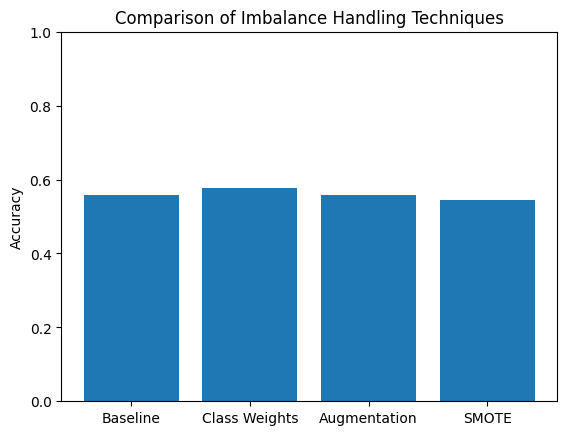

In [116]:
methods = ["Baseline","Class Weights","Augmentation","SMOTE"]
accuracies = [baseline_acc, cw_acc, aug_acc, smote_accuracy]

plt.bar(methods,accuracies)
plt.ylabel("Accuracy")
plt.title("Comparison of Imbalance Handling Techniques")
plt.ylim(0,1)
plt.show()
